## Step 1: Import Required Libraries
This section imports all essential libraries used for file handling, numerical operations, unit conversion,
FITS file reading, plotting, and interaction with CASA data cubes.
Note: CASA functionalities (casatools, casaplotms) are used within the casa_env environment.

In [19]:
import os
os.environ["OMP_DISPLAY_ENV"] = "FALSE"
os.environ["OMP_NUM_THREADS"] = "1"  # Optional: limit threading to avoid verbose logs

In [20]:
# File Access
from glob import glob
# Numerical tasks
from astropy import constants as const
from astropy import units as u
# Plot Generation
from astropy.io import fits
from astropy.visualization import astropy_mpl_style, simple_norm
from astropy.wcs import WCS
from matplotlib.patches import Ellipse
from casatools import image
from casaplotms import plotms

## Step 2: Set Source Parameters and Define Directory Structure

This step sets the target source, molecular line, and rest frequency based on the selected tracer.  
It then defines the main working directory and constructs the paths for spectral data, cleaned images, and other products.

Key actions:
- Selects the source and corresponding rest frequency for the chosen molecular line.
- Sets up subdirectories for storing imaging outputs (`dirty`, `clean`) under a structured folder tree organized by source and line.
- Ensures all required directories exist; creates them if they do not.

In [21]:
source_name = '04108+2803_B'
line = 'C18O'
telescope = 'ALMA'
if line == '13CO':
    restfreq = 330.5879653#GHz
if line == 'C18O':
    restfreq = 329.3305525#GHz
base_dir = '/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks'

spectra_dir = os.path.join(base_dir, 'spectral_data', f'{telescope}_data')
spectra_files = [d for d in os.listdir(spectra_dir) if os.path.isdir(os.path.join(spectra_dir, d)) and d.endswith('contsub.ms')]

source_directory = os.path.join(base_dir, source_name)
if not os.path.exists(source_directory):
    os.makedirs(source_directory)
    print(f'Directory created: {source_directory}')
else:
    print(f'Directory already exists: {source_directory}')

data_directory = os.path.join(base_dir, source_name, 'line', f'{telescope}', 'data')
if not os.path.exists(data_directory):
    os.makedirs(data_directory)
    print(f'Data directory created: {data_directory}')
else:
    print(f'Data directory already exists: {data_directory}')

line_directory = os.path.join(source_directory, 'line', f'{telescope}', f'{line}')
if not os.path.exists(line_directory):
    os.makedirs(line_directory)
    print(f'Line directory created: {line_directory}')
else:
    print(f'Line directory already exists: {line_directory}')

dirty_img = os.path.join(line_directory, f"{source_name}_{line}_dirty")
clean_img = os.path.join(line_directory, f"{source_name}_{line}_clean")

Directory already exists: /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04108+2803_B
Data directory already exists: /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04108+2803_B/line/ALMA/data
Line directory already exists: /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04108+2803_B/line/ALMA/C18O


## Step 3: Split Out Source-Specific Data from .ms Files

This step ensures we isolate the data relevant to the selected source from a collection of `.contsub.ms` measurement sets, each representing a separate observation.

- It loops through all `.contsub.ms` files in the spectral data directory.
- For each file, it checks whether the specified source is present using the FIELD table.
- If the source is found, it uses CASA's `split` task to extract data only for that source and saves it to the appropriate `line/ALMA/data` directory.

In [ ]:
def process_selfcal_files(base_dir, source_name):
    ms = ms_tool()
    tb = table()
    spectral_data_dir = os.path.join(base_dir, 'spectral_data', f'{telescope}_data')
    source_output_dir = os.path.join(base_dir, source_name, 'line', f'{telescope}', 'data')

    # Loop through all .selfcal.ms files in the continuum_data directory
    for filename in os.listdir(spectral_data_dir):
        if filename.endswith('.contsub.ms'):
            file_path = os.path.join(spectral_data_dir, filename)

            try:
                # Open the FIELD table directly to get field names
                field_table_path = file_path + '/FIELD'
                tb.open(field_table_path)
                field_names = tb.getcol("NAME")  # Get field names directly from the FIELD table
                tb.close()

                # Check if the source name exists in the field names
                if source_name in field_names:
                    output_file_path = os.path.join(source_output_dir, f'{source_name}{filename[3:]}')

                    # Use CASA `split` to split the MS based on the source name
                    print(f'Splitting {file_path} to {output_file_path}')
                    split(vis=file_path, outputvis=output_file_path, field=source_name, datacolumn = 'DATA')
                else:
                    print(f'Skipping {file_path} as the field name {source_name} does not exist.')

            except Exception as e:
                print(f"Error processing {file_path}: {e}")
            finally:
                # Ensure MS is closed properly after each file
                ms.close()

    print("Processing complete.")

In [ ]:
process_selfcal_files(base_dir=base_dir, source_name=source_name)

## Step 4: Concatenate Split Measurement Sets

This step combines all previously split `.contsub.ms` files corresponding to the selected source into a single measurement set.

- It searches for all relevant `.contsub.ms` files in the current directory.
- If such files exist, they are concatenated using CASA's `concat` task into a single output file named `{source_name}_contsub.ms`.

This ensures the imaging process in later steps operates on a unified dataset, which is particularly important when the source was observed across multiple executions.

In [10]:
os.chdir(data_directory)
ms_files = sorted(glob("*.contsub.ms"))
if len(ms_files) == 0:
    print("No .contsub.ms files found in the current directory.")
else:
    concat_ms = f"{source_name}_contsub.ms"
    concat(vis=ms_files, concatvis=concat_ms)
    print(f"Concatenation complete! Output MS: {concat_ms}")

2025-04-30 16:17:12	SEVERE	concat::ms::open	Exception Reported: Table file /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04016+2610/line/ALMA/data/04016+2610___A002_Xe44309_X2542_targets.contsub.ms/POINTING/table.dat does not exist
2025-04-30 16:17:12	SEVERE	concat::::casa	Task concat raised an exception of class RuntimeError with the following message: Table file /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04016+2610/line/ALMA/data/04016+2610___A002_Xe44309_X2542_targets.contsub.ms/POINTING/table.dat does not exist


RuntimeError: Table file /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04016+2610/line/ALMA/data/04016+2610___A002_Xe44309_X2542_targets.contsub.ms/POINTING/table.dat does not exist

## Step 5: Visualize UV Coverage (Amplitude vs Frequency)

This step uses CASA's `plotms` tool to generate a diagnostic plot of the UV dataset.

- It plots amplitude as a function of frequency for the target source.
- The visibility data is averaged over scans and baselines but not over spectral windows.
- The output plot (`_amp_vs_freq.png`) helps verify the quality and spectral structure of the visibility data before imaging.

In [11]:
plotms(vis=f'{source_name}_contsub.ms',
       xaxis='frequency',
       yaxis='amp',
       field=source_name,
       avgspw=False,
       avgtime='1e9',  
       avgscan=True,  
       avgbaseline=True,  
       showgui=True,
       plotfile=f'{source_name}_amp_vs_freq.png',
       overwrite = True)

NOTICE: Exporting to images in screen resolution is currently not working.  Switching to high resolution (which is slower, but works).


## Step 6: Perform Spectral Line Imaging with `tclean`

This step uses CASA's `tclean` task to create a spectral line cube from the calibrated measurement set.

- The imaging is done in `cube` mode to capture spectral structure.
- 160 channels are created with a width of 0.25 km/s, starting at –20 km/s in the LSRK frame.
- Multi-scale cleaning is used with `auto-multithresh` masking to clean down to ~5σ.
- Briggs weighting with a taper is used for a balance between resolution and sensitivity.
- The result is a cleaned image cube stored in the variable `clean_img`.

This image cube is the foundation for extracting disk emission and generating moment maps in subsequent steps.

In [9]:
tclean(vis=f"{data_directory}/{source_name}_contsub.ms",
       imagename=clean_img,
       field=source_name,
       spw='',
       #uvrange = '>50klambda',
       specmode='cube',             
       restfreq=restfreq,        
       nchan=160,                   
       start='-20km/s',              
       width='0.25km/s',            
       outframe='LSRK',             
       perchanweightdensity=True,   
       deconvolver='hogbom',      
       gridder='mosaic',          
       imsize=[360, 360],    
       cell='0.1arcsec',   
       weighting='briggsbwtaper',    
       robust=0.5,                   
       restoringbeam='common',      
       usemask='auto-multithresh',                
       noisethreshold=4.25, # not below 3         
       sidelobethreshold=2.0, # maybe 1.5      
       lownoisethreshold=1.5, # maybe 1       
       minbeamfrac=0.3,           
       niter=10000,                  
       nsigma=5.0,                   
       threshold='',  
       interactive=False)           

2025-04-30 16:15:39	SEVERE	tclean::::casa	Task tclean raised an exception of class RuntimeError with the following message: Error in selectData() : Error in selectdata: Table file /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04016+2610/line/ALMA/data/04016+2610_contsub.ms/STATE/table.dat does not exist


RuntimeError: Error in selectData() : Error in selectdata: Table file /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04016+2610/line/ALMA/data/04016+2610_contsub.ms/STATE/table.dat does not exist

## Step 6: Compute Moment Maps

This step generates moment maps from the cleaned spectral line cube.

- **Moment 0** (integrated intensity) shows the total emission from the line at each position.
- **Moment 1** (velocity field) maps the intensity-weighted average velocity, useful for tracing disk rotation.
- The script first computes the RMS noise across the entire cube to define a clipping threshold for masking low-level noise.
- The output moment maps are saved in both `.image` (CASA) and `.fits` (portable) formats.

In [30]:
os.chdir(line_directory)
output_moment0 = f'{source_name}_{line}_moment0.image'
output_moment0_clipped3 = f'{source_name}_{line}_moment0_clipped3.image'
output_moment1 = f'{source_name}_{line}_moment1.image'
output_moment1_clipped3 = f'{source_name}_{line}_moment1_clipped3.image'
fits_moment0 = f'{source_name}_{line}_moment0.fits'
fits_moment0_clipped3 = f'{source_name}_{line}_moment0_clipped3.fits'
fits_moment1 = f'{source_name}_{line}_moment1.fits'
fits_moment1_clipped3 = f'{source_name}_{line}_moment1_clipped3.fits'

In [25]:
# Calculate RMS over the entire data cube
stats = imstat(imagename=f'{source_name}_{line}_clean.residual')
rms_noise = stats['rms'][0]
print(f'RMS Noise (entire cube): {rms_noise:.5f} Jy/beam')
clip_min = 3 * rms_noise  # 3 times the RMS noise for clipping low-level noise
clip_max = 1e10  # Upper limit just to include all significant emission

RMS Noise (entire cube): 0.00668 Jy/beam


In [12]:
# Moment 0 map 

input_cube = f'{source_name}_{line}_clean.image' 
# w/o clipping
immoments(imagename=input_cube,
          moments=[0],  # Moment 0 for integrated intensity
          outfile=output_moment0)
# w/ clipping
immoments(imagename=input_cube,
          moments=[0],  # Moment 0 for integrated intensity
          outfile=output_moment0_clipped3,
          includepix=[clip_min, clip_max])

In [18]:
# Moment 1 Map 

input_cube = f'{source_name}_{line}_clean.image' 
# w/o clipping
immoments(imagename=input_cube,
          moments=[1],  # Moment 1 map
          outfile=output_moment1,
          includepix=[clip_min, clip_max], 
          )

# w/ clipping
immoments(imagename=input_cube,
          moments=[1],  # Moment 1 map
          outfile=output_moment1_clipped3,
          includepix=[clip_min, clip_max], 
          )

In [32]:
exportfits(imagename=output_moment0, fitsimage=fits_moment0, overwrite=True)
exportfits(imagename=output_moment1, fitsimage=fits_moment1, overwrite=True)
#exportfits(imagename=output_moment0_clipped3, fitsimage=fits_moment0_clipped3, overwrite=True)
exportfits(imagename=output_moment1_clipped3, fitsimage=fits_moment1_clipped3, overwrite=True)

## Step 7: Plot Moment Map

This step visualizes the moment map from a FITS file using WCS information, zoomed around the source center for clear inspection.

In [18]:
# Beam info
def get_beam_info(fits_file):
    """
    Extract beam size and pixel scale information from a FITS file header.
    """
    # Open the FITS file and get the header
    hdu = fits.open(fits_file)[0]
    header = hdu.header

    # Extract the beam size from the header
    bmaj = header.get('BMAJ', None)  # major axis in degrees
    bmin = header.get('BMIN', None)  # minor axis in degrees
    bpa = header.get('BPA', 0)       # position angle in degrees, default to 0 if not present

    # Convert beam size from degrees to arcseconds
    bmaj_arcsec = bmaj * 3600 if bmaj else 0
    bmin_arcsec = bmin * 3600 if bmin else 0

    # Convert pixel scale to arcseconds
    pixel_scale_x_deg = abs(header['CDELT1'])  
    pixel_scale_y_deg = abs(header['CDELT2'])  

    pixel_scale_x_arcsec = pixel_scale_x_deg * 3600
    pixel_scale_y_arcsec = pixel_scale_y_deg * 3600

    # Get the width and height of the image in pixels
    if hdu.data.ndim > 2:
        width = hdu.data.shape[3]  # Width of the image in pixels
        height = hdu.data.shape[2]  # Height of the image in pixels
    else:
        width = hdu.data.shape[1]  # Width of the image in pixels
        height = hdu.data.shape[0]  # Height of the image in pixels

    # Convert beam sizes to pixels
    beam_major_pix = bmaj_arcsec / pixel_scale_x_arcsec if bmaj else 0
    beam_minor_pix = bmin_arcsec / pixel_scale_y_arcsec if bmin else 0

    return {
        'bmaj_arcsec': bmaj_arcsec,
        'bmin_arcsec': bmin_arcsec,
        'bpa': bpa,
        'pixel_scale_x_arcsec': pixel_scale_x_arcsec,
        'pixel_scale_y_arcsec': pixel_scale_y_arcsec,
        'width': width,
        'height': height,
        'beam_major_pix': beam_major_pix,
        'beam_minor_pix': beam_minor_pix
    }

In [19]:
beam_info_moment0 = get_beam_info(fits_moment0)
beam_info_moment1 = get_beam_info(fits_moment1)

In [20]:
print(beam_info_moment0)

{'bmaj_arcsec': 0.292055947422516, 'bmin_arcsec': 0.209430547224156, 'bpa': 18.01252459146, 'pixel_scale_x_arcsec': 0.100000000000008, 'pixel_scale_y_arcsec': 0.100000000000008, 'width': 360, 'height': 360, 'beam_major_pix': 2.9205594742249263, 'beam_minor_pix': 2.0943054722413925}


In [41]:
# Plot Moment 0 and Moment 1 maps from FITS files with the beam size and scale bar.
def plot_moments(fits_file, line, source_name, d_AU, beam_info, source_center_pixels, zoom_margin):
    # Open the FITS file and extract data and WCS
    hdu = fits.open(fits_file)[0]
    wcs = WCS(hdu.header)

    # Handle multidimensional data
    if hdu.data.ndim > 2:
        # Slice the data for the first two spatial dimensions
        data_to_plot = hdu.data[0, 0, :, :]
        width = hdu.data.shape[3]
        height = hdu.data.shape[2]
        slices = (0, 0, slice(None), slice(None))  # Adjust slices for WCS
    else:
        data_to_plot = hdu.data[:, :]
        width = hdu.data.shape[1]
        height = hdu.data.shape[0]
        slices = (slice(None), slice(None))  # No slicing needed for 2D data

    # Extract the source center in pixels
    x_center, y_center = source_center_pixels

    # Define zoom limits with the provided source center and margin
    zoom_width = int((width * zoom_margin) / 2)
    zoom_height = int((height * zoom_margin) / 2)

    xmin = max(0, x_center - zoom_width)
    xmax = min(width, x_center + zoom_width)
    ymin = max(0, y_center - zoom_height)
    ymax = min(height, y_center + zoom_height)

    # Subset the data to plot
    data_to_plot = data_to_plot[ymin:ymax, xmin:xmax]

    # Set up the plot
    plt.style.use(astropy_mpl_style)

    # Adjust WCS slicing if necessary
    if slices:
        sliced_wcs = wcs.slice(slices[::-1])  # Reverse the order of slices
    else:
        sliced_wcs = wcs

    fig, ax = plt.subplots(subplot_kw={'projection': sliced_wcs})
    norm = simple_norm(data_to_plot, 'linear')

    # Set color based on telescope
    telescope = beam_info.get("telescope", "")
    clr = 'white' if telescope in ['ALMA', 'SMA'] else 'black'

    # Display the image
    im = ax.imshow(data_to_plot, origin='lower', cmap='jet', norm=norm)

    # Add color bar
    cbar = plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
    cbar.set_label("Flux (Jy/beam)", fontsize=12)

    # Add source name
    ax.text(0.05, 0.95, source_name, transform=ax.transAxes, fontsize=12, color=clr, ha='left', va='top')

    # Adjust beam size to the zoomed region
    zoom_width_actual = xmax - xmin
    zoom_height_actual = ymax - ymin
    if 'beam_major_arcsec' in beam_info and 'beam_minor_arcsec' in beam_info:
        beam_major_pix = beam_info['beam_major_arcsec'] / beam_info['pixel_scale_x_arcsec']
        beam_minor_pix = beam_info['beam_minor_arcsec'] / beam_info['pixel_scale_y_arcsec']

        beam_ellipse = Ellipse(
            xy=(0.1 * (xmax - xmin), 0.1 * (ymax - ymin)), # position in the zoomed region
            width=beam_major_pix,
            height=beam_minor_pix,
            edgecolor=clr,
            facecolor='none',  # Transparent inside
            lw=1,
            angle=beam_info.get('bpa', 0)
        )
        ax.add_patch(beam_ellipse)

    # Calculate the scale bar in pixels relative to the zoomed region
    scale_bar = 100  # in AU
    angular_size_arcsec = (scale_bar / d_AU.value) * 206265
    
    # Ensure pixel_scale_x_arcsec is treated as a float
    if hasattr(beam_info['pixel_scale_x_arcsec'], 'value'):
        pixel_scale_x = beam_info['pixel_scale_x_arcsec'].value
    else:
        pixel_scale_x = float(beam_info['pixel_scale_x_arcsec'])
    
    # Now compute scale bar in pixels
    scale_bar_pix = angular_size_arcsec / pixel_scale_x
    
    # Get the actual axis limits (in pixel space)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Define coordinates for the scale bar **within the zoomed-in region**
    scale_bar_x_start = xlim[0] + 0.05 * (xlim[1] - xlim[0])  # 5% from left edge
    scale_bar_x_end = scale_bar_x_start + scale_bar_pix
    scale_bar_y = ylim[0] + 0.05 * (ylim[1] - ylim[0])  # 5% from bottom edge
    
    # Draw the scale bar
    ax.plot([scale_bar_x_start, scale_bar_x_end], [scale_bar_y, scale_bar_y], color=clr, lw=2)
    
    # Add scale bar label directly below the line
    ax.text(
        (scale_bar_x_start + scale_bar_x_end) / 2,
        scale_bar_y - 0.03 * (ylim[1] - ylim[0]),  # Offset vertically
        f"{scale_bar} AU",
        color=clr,
        fontsize=10,
        ha='center',
        va='center'
    )

    # Disable the grid
    ax.grid(False)

    # Set axis labels
    ax.set_xlabel('RA (J2000)')
    ax.set_ylabel('Dec (J2000)')

    # Add a title to the plot
    wvl = "0.87mm" if telescope == "ALMA" else "9mm" if telescope == "VLA" else "1.3mm" if telescope == "SMA" else ""
    title_text = f"{source_name} {wvl}"
    ax.set_title(title_text, fontsize=14, color='black')

    # Save the plot
    plt.savefig(f'{source_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


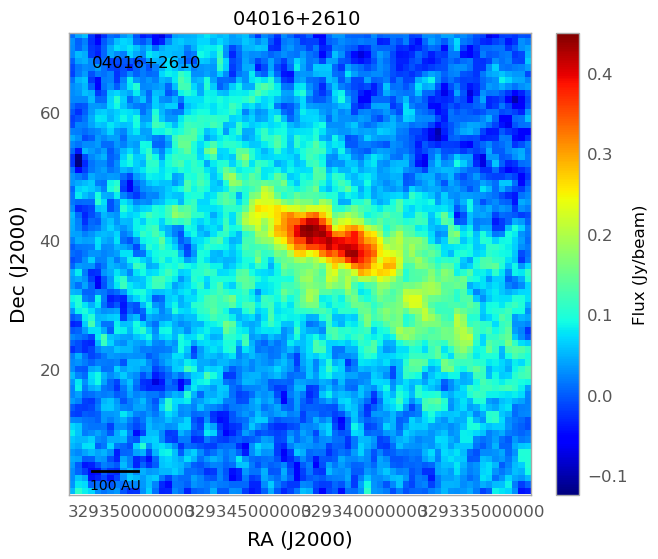

In [45]:
d_AU = (140 * u.pc).to(u.au)
zoom_margin = 0.2
source_center_pixels = (178, 178)
plot_moments(f'{source_name}_{line}_moment0.fits', line, source_name, d_AU, beam_info_moment0, source_center_pixels, zoom_margin)

In [ ]:
# Plot and save Moment 1 map
    plt.figure(figsize=(7, 7))
    ax1 = plt.subplot(111, projection=wcs1)
    norm1 = simple_norm(data1, 'linear')
    im1 = ax1.imshow(data1, origin='lower', cmap='coolwarm', norm=norm1)
    ax1.set_title(f'{source_name} - {line_name} - Moment 1')
    plt.colorbar(im1, ax=ax1, label='Velocity (km/s)')
    ax1.set_xlim(xmin, xmax)
    ax1.set_ylim(ymin, ymax)
    plt.savefig(f'{source_name}_{line_name}_moment1_map.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()